# Sign Language CNN-LSTM Live Prediction
Real-time sign language detection from webcam video

## 1. Import Required Libraries

In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import time
from pathlib import Path

print(" All libraries imported successfully!")

 All libraries imported successfully!


## 2. Device Setup

In [2]:
# Check available device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")

Using CPU
Device: cpu


## 3. Define CNN_LSTM Model

In [3]:
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes, hidden_size=256, num_layers=1):
        super(CNN_LSTM, self).__init__()
        resnet = models.resnet18(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])
        self.feature_dim = resnet.fc.in_features
        self.lstm = nn.LSTM(self.feature_dim, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        batch_size, seq_len, C, H, W = x.size()
        features = []
        for t in range(seq_len):
            f = self.cnn(x[:, t, :, :, :])
            f = f.view(batch_size, -1)
            features.append(f)
        features = torch.stack(features, dim=1)
        lstm_out, _ = self.lstm(features)
        out = lstm_out[:, -1, :]
        return self.fc(out)

print("✅ CNN_LSTM model class defined")

✅ CNN_LSTM model class defined


## 4. Configuration & Model Loading

In [6]:
# Configuration
NUM_CLASSES = 3  # W1, W2, W3
SEQUENCE_LENGTH = 16
IMG_SIZE = 224
MODEL_PATH = "./bdsl_best_cnn_lstm_model.pth"
FRAMES_OUTPUT_DIR = "./extracted_frames"

# Create output directory
os.makedirs(FRAMES_OUTPUT_DIR, exist_ok=True)

# Class names
class_names = ['W1', 'W2', 'W3']

# Sign Language Mapping
SIGN_LANGUAGE_MAPPING = {
    'W1': 'HELLO',
    'W2': 'THANK YOU',
    'W3': 'YES'
}

SIGN_DESCRIPTIONS = {
    'W1': '👋 HELLO - Waving hand gesture greeting',
    'W2': '🙏 THANK YOU - Hands together in gratitude',
    'W3': '👍 YES - Thumbs up affirmative gesture'
}

print("\nConfiguration:")
print(f"  Classes: {NUM_CLASSES}")
print(f"  Sequence Length: {SEQUENCE_LENGTH}")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Model: {MODEL_PATH}")
print(f"  Classes: {class_names}")


Configuration:
  Classes: 3
  Sequence Length: 16
  Image Size: 224x224
  Model: ./bdsl_best_cnn_lstm_model.pth
  Classes: ['W1', 'W2', 'W3']


## 5. Load Pre-trained Model

In [7]:
# Initialize and load model
model = CNN_LSTM(num_classes=NUM_CLASSES).to(device)

if os.path.exists(MODEL_PATH):
    try:
        model_path = Path(MODEL_PATH)

        if model_path.suffix.lower() not in {".pt", ".pth"}:
            raise RuntimeError(
            f"'{MODEL_PATH}' is not a PyTorch checkpoint. "
            "This notebook expects a .pt/.pth state_dict, not a .h5 Keras model."
            )

        checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
        if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
            checkpoint = checkpoint["state_dict"]

        model.load_state_dict(checkpoint)
    except Exception as e:
        raise RuntimeError(
            f"Cannot load '{MODEL_PATH}' with torch.load(). "
            "The file appears to be an HDF5/Keras model (.h5), not a PyTorch checkpoint. "
            "Use a PyTorch .pth/.pt state_dict for this notebook."
        ) from e
    print(f"✅ Model loaded from {MODEL_PATH}")
else:
    print(f"❌ Model file not found at {MODEL_PATH}")
    print(f"   Available files in current directory: {os.listdir('.')[:5]}")

model.eval()
print("✅ Model set to evaluation mode")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Total Parameters: {total_params:,}")

✅ Model loaded from ./bdsl_best_cnn_lstm_model.pth
✅ Model set to evaluation mode
✅ Total Parameters: 11,965,763


## 6. Transform Pipeline

In [ ]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("Transform pipeline defined")

Transform pipeline defined


## 7. Webcam Capture & Frame Extraction

In [ ]:
def capture_video_and_extract_frames(num_frames=SEQUENCE_LENGTH, output_dir=FRAMES_OUTPUT_DIR, save_images=True):
    """
    Capture live video from webcam and extract individual frames as images.
    """
    print("\n" + "="*70)
    print("🎥 LIVE VIDEO CAPTURE & FRAME EXTRACTION")
    print("="*70 + "\n")
    
    # Clear previous frames
    if save_images:
        for file in os.listdir(output_dir):
            if file.endswith('.png'):
                os.remove(os.path.join(output_dir, file))
        print(f"✅ Cleared previous frames from {output_dir}\n")
    
    try:
        cap = cv2.VideoCapture(0)
        
        if not cap.isOpened():
            print("❌ Webcam not accessible. Please check camera permissions.")
            return None, None
        
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
        cap.set(cv2.CAP_PROP_FPS, 30)
        
        frames = []
        image_paths = []
        
        print(f"📷 Starting live capture: {num_frames} frames needed\n")
        start_time = time.time()
        frame_count = 0
        
        while len(frames) < num_frames:
            ret, frame = cap.read()
            if not ret:
                break
            
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
            
            if save_images:
                frame_num = len(frames)
                filename = f"frame_{frame_num:03d}.png"
                filepath = os.path.join(output_dir, filename)
                frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
                cv2.imwrite(filepath, frame_bgr)
                image_paths.append(filepath)
            
            frame_count += 1
            progress = len(frames) / num_frames
            bar_length = 40
            filled = int(bar_length * progress)
            bar = '█' * filled + '░' * (bar_length - filled)
            
            elapsed = time.time() - start_time
            fps = frame_count / elapsed if elapsed > 0 else 0
            eta = (num_frames - len(frames)) / fps if fps > 0 else 0
            
            status = f"[{bar}] {len(frames)}/{num_frames} | FPS: {fps:.1f} | ETA: {eta:.1f}s"
            print(f"\r{status}", end='', flush=True)
        
        cap.release()
        elapsed = time.time() - start_time
        
        print(f"\n\nVideo capture completed!")
        print(f"   • Frames: {len(frames)} in {elapsed:.2f}s")
        print(f"   • FPS: {len(frames)/elapsed:.1f}")
        if save_images:
            print(f"   • Saved to: {output_dir}/")
        print(f"\n{'='*70}\n")
        
        return frames, image_paths
        
    except Exception as e:
        print(f"❌ Error: {str(e)}")
        return None, None

print(" Webcam capture function defined")

 Webcam capture function defined


## 8. Frame Processing & Prediction

In [ ]:
def preprocess_frames(frames, transform_pipeline):
    """Preprocess raw frames for model input."""
    processed_frames = []
    for i, frame in enumerate(frames):
        try:
            img = Image.fromarray(frame.astype('uint8'))
            img_tensor = transform_pipeline(img)
            processed_frames.append(img_tensor)
        except Exception as e:
            print(f"⚠️  Error processing frame {i}: {str(e)}")
            return None
    
    if len(processed_frames) == 0:
        return None
    
    frames_tensor = torch.stack(processed_frames).unsqueeze(0)
    return frames_tensor

def predict_sign(model, frames_tensor, device, class_names):
    """Run model prediction on frames."""
    try:
        frames_tensor = frames_tensor.to(device)
        
        with torch.no_grad():
            output = model(frames_tensor)
            probabilities = torch.softmax(output, dim=1)
            confidence, predicted_class_idx = torch.max(probabilities, 1)
        
        predicted_idx = predicted_class_idx.item()
        predicted_class = class_names[predicted_idx] if predicted_idx < len(class_names) else "Unknown"
        confidence_score = confidence.item() * 100
        
        probs_dict = {}
        for i, class_name in enumerate(class_names):
            probs_dict[class_name] = f"{probabilities[0][i].item()*100:.2f}%"
        
        return {
            'predicted_class': predicted_class,
            'confidence': f"{confidence_score:.2f}%",
            'predicted_text': SIGN_LANGUAGE_MAPPING.get(predicted_class, predicted_class),
            'description': SIGN_DESCRIPTIONS.get(predicted_class, f'Sign: {predicted_class}'),
            'all_probabilities': probs_dict
        }
    
    except Exception as e:
        print(f"❌ Error: {str(e)}")
        return None

print(" Processing and prediction functions defined")

 Processing and prediction functions defined


## 9. Display Functions

In [ ]:
def display_frames(frames, prediction_result=None):
    """Display extracted frames in a grid with prediction visual."""
    num_frames = len(frames)
    if num_frames == 0:
        print(" No frames to display")
        return
    
    cols = 4
    rows = (num_frames + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows*4))
    
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    axes = axes.flatten()
    
    for idx, frame in enumerate(frames):
        ax = axes[idx]
        ax.imshow(frame)
        ax.set_title(f'Frame {idx+1}/{num_frames}', fontsize=11, fontweight='bold')
        ax.axis('off')
    
    for idx in range(num_frames, len(axes)):
        axes[idx].axis('off')
    
    # Visual Output title
    title = "Live Captured Frames"
    if prediction_result:
        title = f"PREDICTION: {prediction_result['predicted_text']} ({prediction_result['predicted_class']})  |  CONFIDENCE: {prediction_result['confidence']}"
        fig.suptitle(title, fontsize=20, fontweight='bold', y=1.02, color='darkblue')
    else:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
        
    plt.tight_layout()
    plt.show()
    print(f"Displayed {num_frames} frames with visual prediction")



## 10. Complete Pipeline: Video → Frames → Prediction

In [ ]:
def run_sign_language_pipeline(num_frames=SEQUENCE_LENGTH, save_frames=True, show_frames=True):
    """
    Complete pipeline:
    1. Capture live video
    2. Preprocess for model
    3. Predict sign language
    4. Display frames with prediction visual
    5. Display print results
    """
    
    print("\n" + "█"*70)
    print("█" + " "*68 + "█")
    print("█" + "  🎬 WEBCAM → FRAMES → SIGN PREDICTION  ".center(68) + "█")
    print("█" + " "*68 + "█")
    print("█"*70 + "\n")
    
    # Step 1: Capture
    print("STEP 1️  Live Video Capture...\n")
    frames, image_paths = capture_video_and_extract_frames(num_frames, FRAMES_OUTPUT_DIR, save_frames)
    
    if frames is None or len(frames) < num_frames:
        print(" Failed to capture frames")
        return None
    
    # Step 2: Preprocess
    print("\nSTEP 2  Preprocessing...\n")
    frames_tensor = preprocess_frames(frames, transform)
    if frames_tensor is None:
        print(" Preprocessing failed")
        return None
    print(f"Tensor shape: {frames_tensor.shape}")
    
    # Step 3: Predict
    print("\nSTEP 3️ Predicting Sign...\n")
    result = predict_sign(model, frames_tensor, device, class_names)
    
    if result is None:
        print("❌ Prediction failed")
        return None
        
    # Step 4: Display frames heavily visual
    if show_frames:
        print("\nSTEP 4  Displaying Visual Results...\n")
        display_frames(frames, prediction_result=result)
    
    # Step 5: Display results
    print("\nSTEP 5️⃣  Console Results\n")
    print("="*70)
    print(f" Sign Detected: {result['predicted_class']}")
    print(f"English Text: {result['predicted_text']}")
    print(f"{result['description']}")
    print(f"Confidence: {result['confidence']}")
    print(f"\n Class Probabilities:")
    for class_name, prob in result['all_probabilities'].items():
        prob_val = float(prob.rstrip('%'))
        bar = '█' * int(prob_val / 5) + '░' * (20 - int(prob_val / 5))
        print(f"   {class_name} │ {bar} │ {prob}")
    print("="*70 + "\n")
    
    return result



## 11. Execute Pipeline


██████████████████████████████████████████████████████████████████████
█                                                                    █
█                🎬 WEBCAM → FRAMES → SIGN PREDICTION                 █
█                                                                    █
██████████████████████████████████████████████████████████████████████

STEP 1️  Live Video Capture...


🎥 LIVE VIDEO CAPTURE & FRAME EXTRACTION

✅ Cleared previous frames from ./extracted_frames

📷 Starting live capture: 16 frames needed

[████████████████████████████████████████] 16/16 | FPS: 15.1 | ETA: 0.0s

Video capture completed!
   • Frames: 16 in 1.37s
   • FPS: 11.7
   • Saved to: ./extracted_frames/



STEP 2  Preprocessing...

Tensor shape: torch.Size([1, 16, 3, 224, 224])

STEP 3️ Predicting Sign...


STEP 4  Displaying Visual Results...



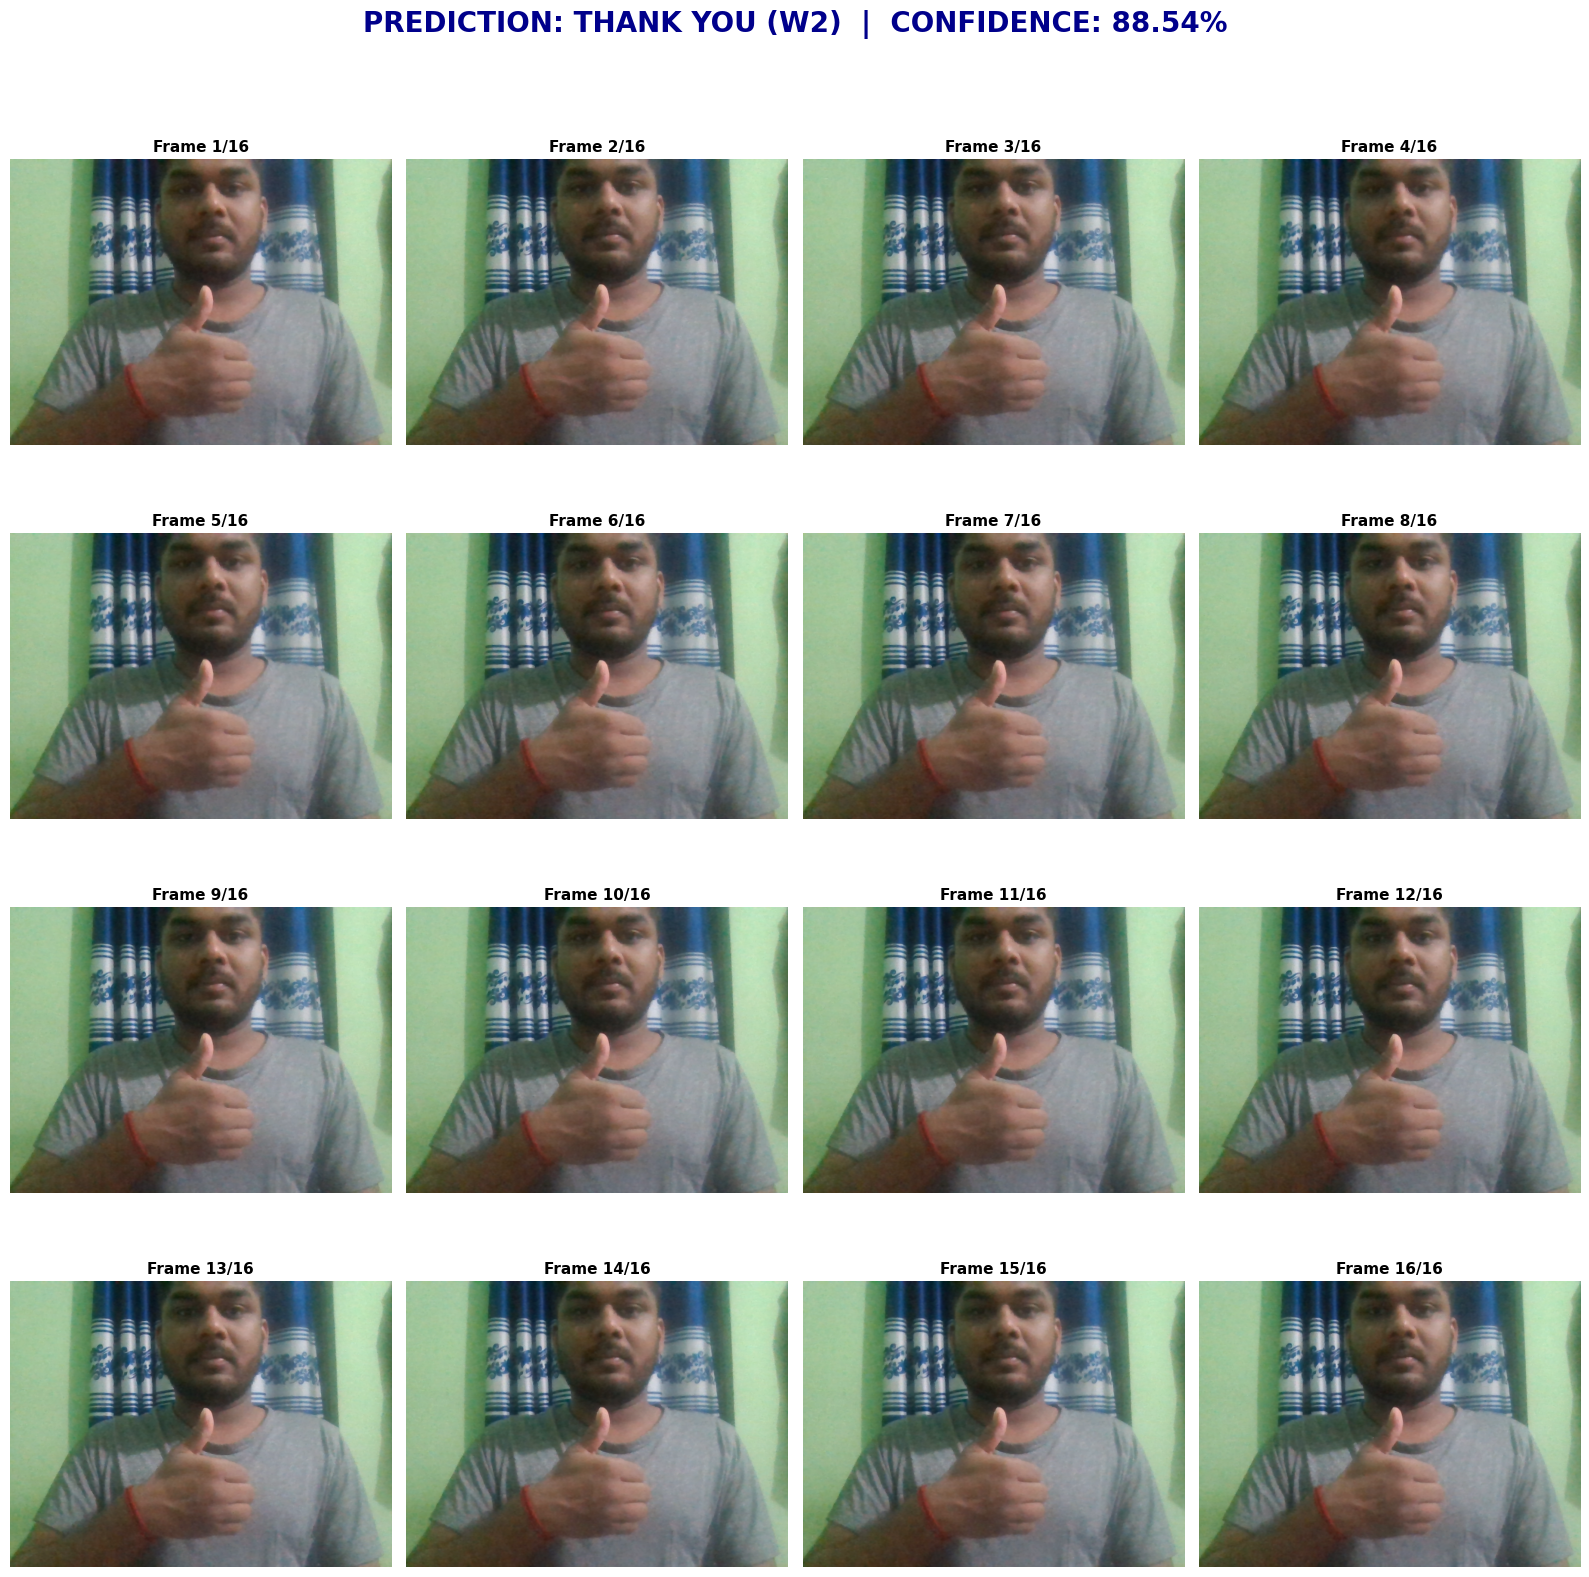

Displayed 16 frames with visual prediction

STEP 5️⃣  Console Results

 Sign Detected: W2
English Text: THANK YOU
🙏 THANK YOU - Hands together in gratitude
Confidence: 88.54%

 Class Probabilities:
   W1 │ █░░░░░░░░░░░░░░░░░░░ │ 7.63%
   W2 │ █████████████████░░░ │ 88.54%
   W3 │ ░░░░░░░░░░░░░░░░░░░░ │ 3.83%

COMPLETED TEST VISUALLY


In [ ]:
# VISUAL TEST EXECUTION:
# This actually runs the live model taking from webcam and displaying result with visually
result = run_sign_language_pipeline(num_frames=SEQUENCE_LENGTH, save_frames=True, show_frames=True)

print("COMPLETED TEST VISUALLY")
print("="*70)

